## Deteksi penyakit pada padi
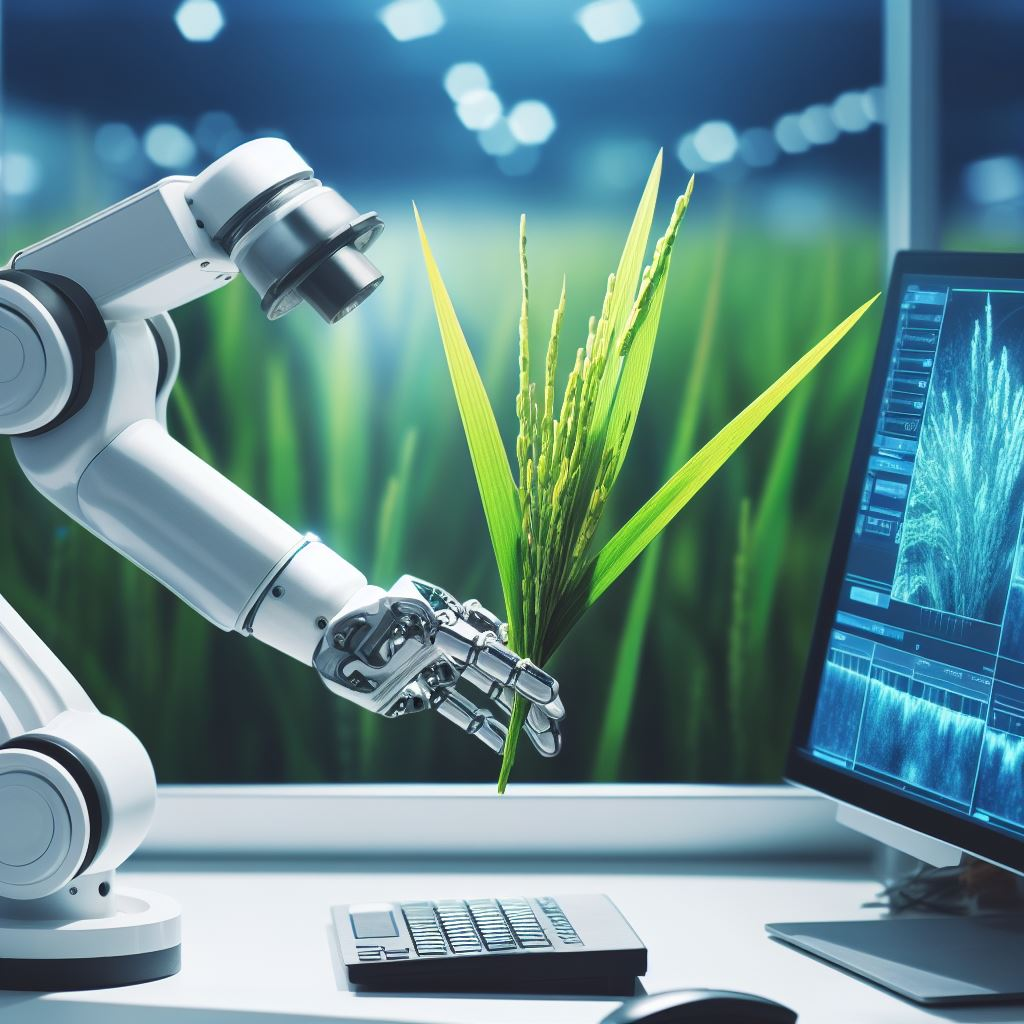

In [20]:
# import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from keras import regularizers
import os
import seaborn as sns
import tensorflow as tf
import keras
from keras.preprocessing import image
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adamax
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split


In [21]:
LIMIT = 1300
IMG_SIZE = (100, 100)
NUM_AUGMENTATIONS_PER_IMAGE = 3
# LABELS = np.array(['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro'])
LABELS = np.array(['Hispa', 'LeafBlast', 'BrownSpot', 'Healthy'])
TRAIN_SPLIT_RATIO = 0.8
TEST_SPLIT_RATIO = 0.5
dir = 'datasets/Rice Diseases Image Dataset'

In [22]:
# Load data
def load_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    for i, folder_name in enumerate(LABELS):
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for j, filename in enumerate(os.listdir(folder_path)):
            if j == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(i)
        print(f"Loaded {len(data)} images from {folder_name}")
    
    return np.array(data), np.array(labels)


In [23]:
X_train, y_train = load_images_from_directory(f'{dir}/train/', LIMIT)
X_test, y_test = load_images_from_directory(f'{dir}/validation/', LIMIT)

400 images in Hispa
Loaded 400 images from Hispa
400 images in LeafBlast
Loaded 800 images from LeafBlast
400 images in BrownSpot
Loaded 1200 images from BrownSpot
400 images in Healthy
Loaded 1600 images from Healthy
123 images in Hispa
Loaded 123 images from Hispa
123 images in LeafBlast
Loaded 246 images from LeafBlast
123 images in BrownSpot
Loaded 369 images from BrownSpot
123 images in Healthy
Loaded 492 images from Healthy


In [24]:
augmented_X_train, augmented_y_train = load_images_from_directory(f'{dir}/augmented_images/', LIMIT)

1200 images in Hispa
Loaded 1200 images from Hispa
1200 images in LeafBlast
Loaded 2400 images from LeafBlast
1200 images in BrownSpot
Loaded 3600 images from BrownSpot
1200 images in Healthy
Loaded 4800 images from Healthy


In [25]:
X_train_augmented = np.append(X_train, augmented_X_train, axis=0)
y_train_augmented = np.append(y_train, augmented_y_train, axis=0)

In [26]:
print(y_train_augmented.shape)

(6400,)


In [27]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=TEST_SPLIT_RATIO, random_state=42)

In [28]:
y_train_augmented = to_categorical(y_train_augmented)
y_test =  to_categorical(y_test)
y_val = to_categorical(y_val)

In [29]:
print(y_train_augmented.shape, y_test.shape, y_val.shape)

(6400, 4) (246, 4) (246, 4)


In [30]:
datagen = ImageDataGenerator(horizontal_flip=True,vertical_flip=True,rotation_range=20,zoom_range=0.2,
                        width_shift_range=0.2,height_shift_range=0.2,shear_range=0.1,fill_mode="nearest")

In [31]:
pretrained_model3 = tf.keras.applications.DenseNet201(input_shape=(100,100,3),include_top=False,weights='imagenet',pooling='avg')
pretrained_model3.trainable = False

In [32]:
inputs3 = pretrained_model3.input
x3 = tf.keras.layers.Dense(128, activation='relu')(pretrained_model3.output)
outputs3 = tf.keras.layers.Dense(len(LABELS), activation='softmax')(x3)
model = tf.keras.Model(inputs=inputs3, outputs=outputs3)

In [33]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [34]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 106, 106,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 50, 50,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 50, 50,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 50, 50,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 52, 52,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 25, 25,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 25, 25,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 25, 25,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 25, 25,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 25, 25,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 25, 25,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 25, 25,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 25, 25,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 25, 25,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 25, 25,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 25, 25,    │     12,288 │ conv2_block2_0_r

 Total params: 18,568,388 (70.83 MB)

 Trainable params: 246,404 (962.52 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [35]:
his=model.fit(datagen.flow(X_train_augmented,y_train_augmented,batch_size=32),validation_data=(X_val,y_val),epochs=30)

c:\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.3789 - loss: 3.3429 - val_accuracy: 0.3537 - val_loss: 1.5775
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.4244 - loss: 1.3740 - val_accuracy: 0.4268 - val_loss: 1.3166
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.4563 - loss: 1.2063 - val_accuracy: 0.4512 - val_loss: 1.2242
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.4633 - loss: 1.1826 - val_accuracy: 0.4553 - val_loss: 1.2157
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.4708 - loss: 1.1399 - val_accuracy: 0.4634 - val_loss: 1.1848
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.4780 - loss: 1.1153 - val_accuracy: 0.5000 - val_loss: 1.1631
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 434s 2s/step - accuracy: 0.4772 - loss: 1.1179 - val_accuracy: 0.4756 - val_loss: 1.1971
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.5044 - loss: 1.1054 - val_accu

KeyboardInterrupt: 

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(dataset, labels, train_size=TRAIN_SPLIT_RATIO, random_state=42)
# X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=TEST_SPLIT_RATIO, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, log_loss, accuracy_score

y_pred=model.predict(X_val)
pred=np.argmax(y_pred,axis=1)
ground = np.argmax(y_val,axis=1)
print(classification_report(ground,pred))

28/28 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       0.97      1.00      0.98       181
           2       1.00      1.00      1.00       192
           3       1.00      0.97      0.99       222
           4       1.00      1.00      1.00       193

    accuracy                           0.99       869
   macro avg       0.99      0.99      0.99       869
weighted avg       0.99      0.99      0.99       869



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


# Confusion Matrix
cm = confusion_matrix(ground, pred)



# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=LABELS,
            yticklabels=LABELS)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

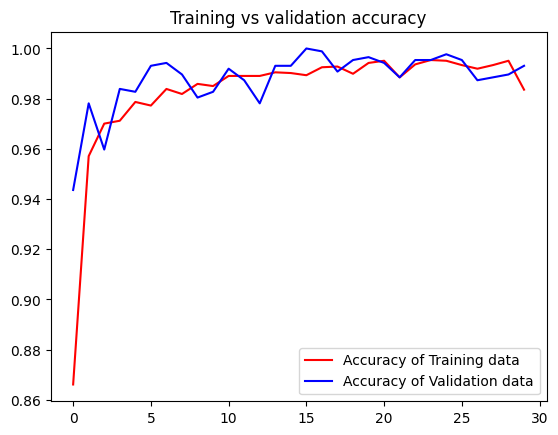

<Figure size 640x480 with 0 Axes>

In [ ]:
get_acc = his.history['accuracy']
value_acc = his.history['val_accuracy']
get_loss = his.history['loss']
validation_loss = his.history['val_loss']

epochs = range(len(get_acc))
plt.plot(epochs, get_acc, 'r', label='Accuracy of Training data')
plt.plot(epochs, value_acc, 'b', label='Accuracy of Validation data')
plt.title('Training vs validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()

In [ ]:
model.save('new_dataset_model.keras')

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow import lite

converter = lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmp12t9gj89'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134210798397264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210798397456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210798394768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210798395920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210798394384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210798395728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210798396880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210796569040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210798394576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134210796637456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13421079663937

In [ ]:
with open('new_dataset_model.tflite', 'wb') as f:
    f.write(tflite_model)

In [ ]:
from sklearn.metrics import classification_report



y_pred = model.predict(X_test)
pred = np.argmax(y_pred, axis=1)
ground = np.argmax(y_test, axis=1)


report = classification_report(ground, pred, target_names=LABELS, output_dict=True)


class_names = list(report.keys())[:-3]
accuracies = [report[class_name]['precision'] for class_name in class_names]


plt.figure(figsize=(8, 5))
plt.bar(class_names, accuracies, color=['red', 'Blue', 'yellow', 'pink', 'green'])
plt.xlabel('Classes')
plt.ylabel('Precision')
plt.title('Precision for Each Class')
plt.ylim(0, 1)  # Sesuaikan dengan rentang akurasi
plt.show()


In [ ]:
from PIL import Image
image_path = f'{dir}/Rice-Leaf-Disease-Images/Bacterialblight/BACTERAILBLIGHT4_166.jpg'
# image_path = 'IMG_4862.jpg'
img = Image.open(image_path)
img = img.resize((100, 100))

# Konversi gambar menjadi array numpy
img_array = np.array(img) / 255.0
print(img_array.shape)
img_array = np.expand_dims(img_array, axis=0)  # Tambahkan dimensi batch
print(img_array.shape)
# Lakukan prediksi menggunakan model H5
# predictions = loaded_model.predict(img_array)
predictions = model.predict(img_array)

print(predictions)

# Konversi hasil prediksi ke dalam persentase
percentage_predictions = tf.nn.softmax(predictions[0]) * 100

print(percentage_predictions)

# Tampilkan hasil prediksi
for class_name, percentage in zip(LABELS, percentage_predictions):
    print(f'{class_name}: {percentage:.2f}%')

(100, 100, 3)
(1, 100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step
[[3.454114e-09 2.295321e-09 6.261581e-11 1.000000e+00 3.547309e-08]]
tf.Tensor([14.884758 14.884758 14.884758 40.460968 14.884758], shape=(5,), dtype=float32)
Tungro: 14.88%
Blast: 14.88%
Brownspot: 14.88%
Bacterialblight: 40.46%
Healthy: 14.88%
